# Mudança climática em Bauru: temperatura e precipitação entre 2002 e 2025

## Contexto

Uma prefeitura precisa compreender se o padrão climático de sua região está mudando para planejar ações de infraestrutura e adaptação. Neste trabalho, será analisada a série histórica da estação meteorológica automática de Bauru, mantida pelo Instituto Nacional de Meteorologia (INMET).

## Pergunta central

Há uma tendência estatisticamente relevante de aumento da temperatura ou mudança no padrão de precipitação em Bauru ao longo da série histórica?

## Objetivos

- Examinar a evolução da temperatura em Bauru entre 2002 e 2025.
- Verificar se existe tendência de aumento da temperatura média.
- Analisar a evolução do volume de precipitação.
- Verificar possíveis mudanças na quantidade de dias chuvosos e na intensidade das chuvas.
- Produzir uma recomendação tecnicamente justificada para o planejamento municipal.

## Fonte dos dados

Instituto Nacional de Meteorologia — INMET  
Estação automática de Bauru: A705  
Período analisado: 2002–2025  
Fonte: https://portal.inmet.gov.br/dadoshistoricos  

## 1. Preparação do ambiente

Nesta etapa são importadas as bibliotecas utilizadas para leitura, tratamento, análise e visualização dos dados.

As principais bibliotecas são:

- `pandas`: manipulação de tabelas e séries temporais;
- `numpy`: operações numéricas;
- `matplotlib` e `seaborn`: construção de gráficos;
- `pathlib`: manipulação portátil dos caminhos;
- `re`: identificação do ano nos nomes e nas pastas;
- `unicodedata`: padronização dos nomes das colunas.

Os arquivos anuais do INMET devem estar descompactados. O notebook procura recursivamente os CSVs da estação A705, portanto aceita uma pasta por ano ou outra organização equivalente.

In [55]:
from pathlib import Path
import os
import re
import unicodedata

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Organização dos arquivos

O projeto usa caminhos relativos: dados brutos em `data/raw`, bases tratadas em `data/processed`, gráficos em `figures` e o notebook em `notebooks`. Dados externos podem ser indicados por `INMET_DADOS_DIR`.

In [56]:
# Localiza automaticamente a raiz do repositório, sem depender do nome
# do usuário ou do diretório em que o projeto foi clonado.
pasta_inicial = Path.cwd().resolve()
candidatas = [pasta_inicial, *pasta_inicial.parents]

PASTA_PROJETO = next(
    (
        pasta
        for pasta in candidatas
        if (pasta / "requirements.txt").exists()
        and (pasta / "notebooks").is_dir()
    ),
    None
)

if PASTA_PROJETO is None:
    raise FileNotFoundError(
        "Não foi possível localizar a raiz do projeto. "
        "Abra o VS Code na pasta tema-4-clima antes de executar o notebook."
    )

PASTA_RAW = PASTA_PROJETO / "data" / "raw"
PASTA_PROCESSED = PASTA_PROJETO / "data" / "processed"
PASTA_FIGURES = PASTA_PROJETO / "figures"

for pasta in (PASTA_RAW, PASTA_PROCESSED, PASTA_FIGURES):
    pasta.mkdir(parents=True, exist_ok=True)

# Configuração opcional para dados descompactados fora do repositório.
pasta_dados_externa = os.environ.get("INMET_DADOS_DIR")
PASTA_DADOS = (
    Path(pasta_dados_externa).expanduser().resolve()
    if pasta_dados_externa
    else PASTA_RAW
)

origem_dados = "variável INMET_DADOS_DIR" if pasta_dados_externa else "data/raw"
print("Raiz do projeto localizada com sucesso.")
print("Origem dos dados descompactados:", origem_dados)

Raiz do projeto localizada com sucesso.
Origem dos dados descompactados: data/raw


## 3. Padronização dos nomes das colunas

Os cabeçalhos dos diferentes anos são normalizados. Mantêm-se data, hora UTC, precipitação, temperatura do ar e temperaturas máxima e mínima.

In [57]:
def normalizar_texto(texto):
    texto = unicodedata.normalize("NFKD", str(texto))
    texto = texto.encode("ascii", "ignore").decode("ascii")
    return texto.strip().upper()


def renomear_colunas_inmet(df):
    novos_nomes = {}

    for coluna in df.columns:
        nome = normalizar_texto(coluna)

        if nome.startswith("DATA"):
            novos_nomes[coluna] = "data"

        elif nome.startswith("HORA"):
            novos_nomes[coluna] = "hora_utc"

        elif nome.startswith("PRECIPITACAO TOTAL"):
            novos_nomes[coluna] = "precipitacao_mm"

        elif nome.startswith("TEMPERATURA DO AR - BULBO SECO"):
            novos_nomes[coluna] = "temperatura_c"

        elif nome.startswith("TEMPERATURA MAXIMA NA HORA ANT"):
            novos_nomes[coluna] = "temperatura_maxima_c"

        elif nome.startswith("TEMPERATURA MINIMA NA HORA ANT"):
            novos_nomes[coluna] = "temperatura_minima_c"

    return df.rename(columns=novos_nomes)

## 4. Extração e consolidação dos dados de Bauru

Os CSVs da estação A705 entre 2002 e 2025 são localizados, validados e reunidos. A leitura ignora as oito linhas iniciais de metadados e considera ponto e vírgula como separador e vírgula como decimal.

In [58]:
# Localiza recursivamente apenas os CSVs da estação A705 de Bauru.
arquivos_bauru = sorted(
    caminho
    for caminho in PASTA_DADOS.rglob("*")
    if caminho.is_file()
    and caminho.suffix.lower() == ".csv"
    and "A705_BAURU" in caminho.name.upper()
)

if not arquivos_bauru:
    raise FileNotFoundError(
        "Nenhum CSV da estação A705 foi encontrado. Descompacte os dados do INMET "
        "em data/raw e mantenha os arquivos que contêm A705_BAURU no nome, "
        "ou defina a variável de ambiente INMET_DADOS_DIR."
    )

# Identifica o ano pelo nome do arquivo e pelas pastas que o contêm.
arquivos_por_ano = {}
for caminho_csv in arquivos_bauru:
    anos_encontrados = {
        int(valor)
        for valor in re.findall(r"(?<!\d)(20\d{2})(?!\d)", str(caminho_csv))
        if 2002 <= int(valor) <= 2025
    }

    if len(anos_encontrados) != 1:
        raise ValueError(
            f"Não foi possível identificar um único ano entre 2002 e 2025 em: {caminho_csv.name}"
        )

    ano = anos_encontrados.pop()
    if ano in arquivos_por_ano:
        raise ValueError(
            f"Mais de um CSV da estação A705 foi encontrado para {ano}. "
            "Mantenha apenas um arquivo desse ano."
        )
    arquivos_por_ano[ano] = caminho_csv

anos_esperados = set(range(2002, 2026))
anos_ausentes = sorted(anos_esperados - set(arquivos_por_ano))

if anos_ausentes:
    raise FileNotFoundError(
        "Faltam CSVs descompactados da estação A705 para os anos: "
        + ", ".join(map(str, anos_ausentes))
        + ". Verifique as pastas em data/raw."
    )

bases = []
arquivos_lidos = []

for ano in sorted(arquivos_por_ano):
    caminho_csv = arquivos_por_ano[ano]

    df_ano = pd.read_csv(
        caminho_csv,
        sep=";",
        decimal=",",
        encoding="latin1",
        skiprows=8,
        na_values=["", "-9999", "-9999.0"]
    )

    df_ano = df_ano.dropna(axis=1, how="all")
    df_ano = renomear_colunas_inmet(df_ano)
    df_ano["ano_arquivo"] = ano

    colunas_necessarias = [
        "data",
        "hora_utc",
        "precipitacao_mm",
        "temperatura_c",
        "temperatura_maxima_c",
        "temperatura_minima_c",
        "ano_arquivo"
    ]

    faltantes = [
        coluna
        for coluna in colunas_necessarias
        if coluna not in df_ano.columns
    ]

    if faltantes:
        raise ValueError(f"{ano}: colunas obrigatórias ausentes: {faltantes}")

    bases.append(df_ano[colunas_necessarias])
    arquivos_lidos.append(ano)

dados_horarios = pd.concat(bases, ignore_index=True)

print("Anos lidos:", arquivos_lidos)
print("Quantidade de registros:", len(dados_horarios))

dados_horarios.head()

Anos lidos: [2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Quantidade de registros: 210384


,data,hora_utc,precipitacao_mm,temperatura_c,temperatura_maxima_c,temperatura_minima_c,ano_arquivo
0,2002-01-01,00:00,0.0,23.1,24.3,23.1,2002
1,2002-01-01,01:00,0.0,23.2,23.5,23.0,2002
2,2002-01-01,02:00,0.0,22.7,23.3,22.7,2002
3,2002-01-01,03:00,0.0,23.0,23.1,22.6,2002
4,2002-01-01,04:00,0.0,23.2,23.7,23.0,2002


## 5. Verificação inicial da base consolidada

São conferidos quantidade de registros, tipos, ausências e observações por ano. Anos incompletos não são excluídos automaticamente; sua cobertura é avaliada nas etapas seguintes.

In [59]:
print(dados_horarios.info())

display(dados_horarios.head())
display(dados_horarios.tail())

print("\nValores ausentes:")
display(dados_horarios.isna().sum())

print("\nRegistros por ano:")
display(
    dados_horarios.groupby("ano_arquivo")
    .size()
    .rename("quantidade")
    .to_frame()
)

<class 'pandas.DataFrame'>
RangeIndex: 210384 entries, 0 to 210383
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   data                  210384 non-null  str    
 1   hora_utc              210384 non-null  str    
 2   precipitacao_mm       187782 non-null  float64
 3   temperatura_c         188795 non-null  float64
 4   temperatura_maxima_c  188394 non-null  float64
 5   temperatura_minima_c  188393 non-null  float64
 6   ano_arquivo           210384 non-null  int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 14.4 MB
None


,data,hora_utc,precipitacao_mm,temperatura_c,temperatura_maxima_c,temperatura_minima_c,ano_arquivo
0,2002-01-01,00:00,0.0,23.1,24.3,23.1,2002
1,2002-01-01,01:00,0.0,23.2,23.5,23.0,2002
2,2002-01-01,02:00,0.0,22.7,23.3,22.7,2002
3,2002-01-01,03:00,0.0,23.0,23.1,22.6,2002
4,2002-01-01,04:00,0.0,23.2,23.7,23.0,2002


,data,hora_utc,precipitacao_mm,temperatura_c,temperatura_maxima_c,temperatura_minima_c,ano_arquivo
210379,2025/12/31,1900 UTC,0.0,26.5,26.6,25.4,2025
210380,2025/12/31,2000 UTC,0.0,23.2,26.5,23.2,2025
210381,2025/12/31,2100 UTC,0.0,22.7,23.2,22.5,2025
210382,2025/12/31,2200 UTC,0.2,22.3,22.9,21.9,2025
210383,2025/12/31,2300 UTC,0.0,22.5,22.7,22.2,2025



Valores ausentes:


data                        0
hora_utc                    0
precipitacao_mm         22602
temperatura_c           21589
temperatura_maxima_c    21990
temperatura_minima_c    21991
ano_arquivo                 0
dtype: int64


Registros por ano:


,quantidade
ano_arquivo,
2002,8760
2003,8760
2004,8784
2005,8760
2006,8760
2007,8760
2008,8784
2009,8760
2010,8760


## 6. Análise da completude por ano

A disponibilidade das variáveis é examinada por ano, pois lacunas extensas podem comprometer os indicadores. A análise principal exige cobertura mínima de 90%.

In [60]:
variaveis_meteorologicas = [
    "precipitacao_mm",
    "temperatura_c",
    "temperatura_maxima_c",
    "temperatura_minima_c"
]

resumo_ausencias = pd.DataFrame({
    "registros_totais": len(dados_horarios),
    "valores_ausentes": (
        dados_horarios[variaveis_meteorologicas]
        .isna()
        .sum()
    ),
    "percentual_ausente": (
        dados_horarios[variaveis_meteorologicas]
        .isna()
        .mean()
        .mul(100)
    )
})

display(resumo_ausencias.round(2))

,registros_totais,valores_ausentes,percentual_ausente
precipitacao_mm,210384,22602,10.74
temperatura_c,210384,21589,10.26
temperatura_maxima_c,210384,21990,10.45
temperatura_minima_c,210384,21991,10.45


In [61]:
ausencias_por_ano = (
    dados_horarios
    .groupby("ano_arquivo")[variaveis_meteorologicas]
    .agg(lambda coluna: coluna.isna().mean() * 100)
)

display(ausencias_por_ano.round(2))

,precipitacao_mm,temperatura_c,temperatura_maxima_c,temperatura_minima_c
ano_arquivo,,,,
2002,34.52,34.47,34.52,34.52
2003,10.88,10.87,11.08,11.08
2004,71.51,70.69,70.72,70.72
2005,6.44,4.54,4.54,4.54
2006,4.16,3.71,3.71,3.71
2007,0.35,0.35,0.35,0.35
2008,0.09,0.09,0.09,0.09
2009,55.70,55.70,55.70,55.70
2010,12.71,12.68,12.69,12.71


## 7. Tratamento da data e do horário

Data e hora UTC são combinadas e convertidas para `America/Sao_Paulo`, respeitando o histórico de horário de verão. Também são verificadas datas inválidas e duplicatas.

In [62]:
# Converte as datas, aceitando os formatos utilizados nos arquivos antigos e novos
dados_horarios["data_convertida"] = pd.to_datetime(
    dados_horarios["data"],
    format="mixed",
    errors="coerce"
)

# Padroniza os dois formatos encontrados: "00:00" e "0000 UTC"
dados_horarios["hora_texto"] = (
    dados_horarios["hora_utc"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)
    .str.zfill(4)
    .str[-4:]
)

# Separa hora e minuto
dados_horarios["hora_numero"] = pd.to_numeric(
    dados_horarios["hora_texto"].str[:2],
    errors="coerce"
)

dados_horarios["minuto_numero"] = pd.to_numeric(
    dados_horarios["hora_texto"].str[2:],
    errors="coerce"
)

# Marca horários fora dos limites válidos
horarios_invalidos = (
    ~dados_horarios["hora_numero"].between(0, 23)
    | ~dados_horarios["minuto_numero"].between(0, 59)
)
dados_horarios.loc[
    horarios_invalidos,
    ["hora_numero", "minuto_numero"]
] = np.nan

# Combina data e horário
dados_horarios["data_hora_utc"] = (
    dados_horarios["data_convertida"]
    + pd.to_timedelta(dados_horarios["hora_numero"], unit="h")
    + pd.to_timedelta(dados_horarios["minuto_numero"], unit="m")
)

# Informa que o horário original está em UTC
dados_horarios["data_hora_utc"] = (
    dados_horarios["data_hora_utc"]
    .dt.tz_localize("UTC")
)

# Converte para o horário local de Bauru
dados_horarios["data_hora_bauru"] = (
    dados_horarios["data_hora_utc"]
    .dt.tz_convert("America/Sao_Paulo")
)

# Cria a data local, sem o componente de horário
dados_horarios["data_local"] = pd.to_datetime(
    dados_horarios["data_hora_bauru"].dt.date
)

display(
    dados_horarios[
        [
            "data",
            "hora_utc",
            "hora_texto",
            "data_hora_utc",
            "data_hora_bauru",
            "data_local"
        ]
    ].head()
)

,data,hora_utc,hora_texto,data_hora_utc,data_hora_bauru,data_local
0,2002-01-01,00:00,0000,2002-01-01 00:00:00+00:00,2001-12-31 22:00:00-02:00,2001-12-31
1,2002-01-01,01:00,0100,2002-01-01 01:00:00+00:00,2001-12-31 23:00:00-02:00,2001-12-31
2,2002-01-01,02:00,0200,2002-01-01 02:00:00+00:00,2002-01-01 00:00:00-02:00,2002-01-01
3,2002-01-01,03:00,0300,2002-01-01 03:00:00+00:00,2002-01-01 01:00:00-02:00,2002-01-01
4,2002-01-01,04:00,0400,2002-01-01 04:00:00+00:00,2002-01-01 02:00:00-02:00,2002-01-01


## 8. Validação da conversão temporal

Os formatos de horário do INMET são padronizados. Datas inválidas são contabilizadas antes da verificação de duplicatas pelo instante UTC.

In [63]:
datas_invalidas = dados_horarios["data_hora_utc"].isna().sum()

duplicatas_validas = (
    dados_horarios
    .dropna(subset=["data_hora_utc"])
    .duplicated(subset="data_hora_utc", keep=False)
    .sum()
)

print("Datas ou horários inválidos:", datas_invalidas)
print("Registros válidos duplicados:", duplicatas_validas)

Datas ou horários inválidos: 0
Registros válidos duplicados: 0


## 9. Delimitação temporal após a conversão

Após a conversão para o horário local, a série é novamente limitada a 01/01/2002–31/12/2025 e eventuais duplicatas UTC são removidas.

In [64]:
dados_horarios = (
    dados_horarios
    .dropna(subset=["data_hora_utc"])
    .drop_duplicates(
        subset="data_hora_utc",
        keep="first"
    )
    .loc[
        lambda df: df["data_local"].between(
            "2002-01-01",
            "2025-12-31"
        )
    ]
    .sort_values("data_hora_utc")
    .reset_index(drop=True)
)

print("Quantidade de registros:", len(dados_horarios))
print("Primeira data local:", dados_horarios["data_local"].min())
print("Última data local:", dados_horarios["data_local"].max())

Quantidade de registros: 210382
Primeira data local: 2002-01-01 00:00:00
Última data local: 2025-12-31 00:00:00


## 10. Controle de qualidade das variáveis meteorológicas

As variáveis são convertidas para números. São identificadas temperaturas fora de −10 °C a 50 °C, precipitações negativas e casos em que a mínima supera a máxima.

In [65]:
# Garante que as variáveis sejam numéricas
for coluna in variaveis_meteorologicas:
    dados_horarios[coluna] = pd.to_numeric(
        dados_horarios[coluna],
        errors="coerce"
    )

temperaturas_improvaveis = (
    (dados_horarios["temperatura_c"] < -10)
    | (dados_horarios["temperatura_c"] > 50)
).sum()

precipitacoes_negativas = (
    dados_horarios["precipitacao_mm"] < 0
).sum()

minima_maior_maxima = (
    dados_horarios["temperatura_minima_c"]
    > dados_horarios["temperatura_maxima_c"]
).sum()

print(
    "Temperaturas fora do intervalo de controle:",
    temperaturas_improvaveis
)

print(
    "Valores negativos de precipitação:",
    precipitacoes_negativas
)

print(
    "Registros com mínima superior à máxima:",
    minima_maior_maxima
)

Temperaturas fora do intervalo de controle: 0
Valores negativos de precipitação: 0
Registros com mínima superior à máxima: 0


### Tratamento dos registros inválidos

Valores inconsistentes são transformados em ausentes, sem imputação, para preservar a variabilidade observada.

In [66]:
dados_horarios.loc[
    (
        (dados_horarios["temperatura_c"] < -10)
        | (dados_horarios["temperatura_c"] > 50)
    ),
    "temperatura_c"
] = np.nan

dados_horarios.loc[
    dados_horarios["precipitacao_mm"] < 0,
    "precipitacao_mm"
] = np.nan

inconsistencia_min_max = (
    dados_horarios["temperatura_minima_c"]
    > dados_horarios["temperatura_maxima_c"]
)

dados_horarios.loc[
    inconsistencia_min_max,
    ["temperatura_minima_c", "temperatura_maxima_c"]
] = np.nan

## 11. Agregação dos registros horários em dados diários

Os registros são agrupados por data local para calcular temperatura média, máxima e mínima, precipitação diária e número de observações válidas. Dias sem medição de chuva permanecem ausentes.

In [67]:
dados_diarios = (
    dados_horarios
    .groupby("data_local")
    .agg(
        temperatura_media_c=(
            "temperatura_c",
            "mean"
        ),
        temperatura_maxima_c=(
            "temperatura_maxima_c",
            "max"
        ),
        temperatura_minima_c=(
            "temperatura_minima_c",
            "min"
        ),
        precipitacao_total_mm=(
            "precipitacao_mm",
            lambda valores: valores.sum(min_count=1)
        ),
        observacoes_temperatura=(
            "temperatura_c",
            "count"
        ),
        observacoes_precipitacao=(
            "precipitacao_mm",
            "count"
        )
    )
    .reset_index()
)

dados_diarios["ano"] = dados_diarios["data_local"].dt.year
dados_diarios["mes"] = dados_diarios["data_local"].dt.month
dados_diarios["dia"] = dados_diarios["data_local"].dt.day

display(dados_diarios.head())
display(dados_diarios.tail())

print("Quantidade de dias:", len(dados_diarios))

,data_local,temperatura_media_c,temperatura_maxima_c,temperatura_minima_c,precipitacao_total_mm,observacoes_temperatura,observacoes_precipitacao,ano,mes,dia
0,2002-01-01,23.104167,27.6,21.5,17.0,24,24,2002,1,1
1,2002-01-02,24.729167,31.7,20.6,0.0,24,24,2002,1,2
2,2002-01-03,25.166667,32.5,17.9,0.0,24,24,2002,1,3
3,2002-01-04,25.104167,31.4,19.9,0.0,24,24,2002,1,4
4,2002-01-05,25.350000,31.9,19.7,0.0,24,24,2002,1,5


,data_local,temperatura_media_c,temperatura_maxima_c,temperatura_minima_c,precipitacao_total_mm,observacoes_temperatura,observacoes_precipitacao,ano,mes,dia
8761,2025-12-27,26.645833,35.2,21.3,2.6,24,24,2025,12,27
8762,2025-12-28,25.033333,35.1,19.4,27.6,24,24,2025,12,28
8763,2025-12-29,26.075000,33.6,19.8,8.4,24,24,2025,12,29
8764,2025-12-30,27.066667,34.2,21.3,1.6,24,24,2025,12,30
8765,2025-12-31,24.238095,30.3,21.2,1.0,21,21,2025,12,31


Quantidade de dias: 8766


## 12. Critério de validade dos dados diários

Um dia é válido para uma variável quando possui pelo menos 22 observações horárias, aproximadamente 90% do dia.

In [68]:
dias_temp_incompletos = (
    dados_diarios["observacoes_temperatura"] < 22
).sum()

dias_chuva_incompletos = (
    dados_diarios["observacoes_precipitacao"] < 22
).sum()

print(
    "Dias com menos de 22 observações de temperatura:",
    dias_temp_incompletos
)

print(
    "Dias com menos de 22 observações de precipitação:",
    dias_chuva_incompletos
)

Dias com menos de 22 observações de temperatura: 1064
Dias com menos de 22 observações de precipitação: 1109


### Aplicação do critério de validade diária

Indicadores de dias incompletos são marcados como ausentes, mas suas contagens são preservadas para auditoria.

In [69]:
dados_diarios.loc[
    dados_diarios["observacoes_temperatura"] < 22,
    [
        "temperatura_media_c",
        "temperatura_maxima_c",
        "temperatura_minima_c"
    ]
] = np.nan

dados_diarios.loc[
    dados_diarios["observacoes_precipitacao"] < 22,
    "precipitacao_total_mm"
] = np.nan

## 13. Avaliação da cobertura anual

A cobertura corresponde à proporção de dias válidos em cada ano. O limite principal é 90%, avaliado separadamente para temperatura e precipitação.

In [70]:
import calendar

cobertura_anual = (
    dados_diarios
    .groupby("ano")
    .agg(
        dias_presentes=(
            "data_local",
            "count"
        ),
        dias_validos_temperatura=(
            "temperatura_media_c",
            "count"
        ),
        dias_validos_precipitacao=(
            "precipitacao_total_mm",
            "count"
        )
    )
    .reset_index()
)

cobertura_anual["dias_esperados"] = (
    cobertura_anual["ano"]
    .apply(lambda ano: 366 if calendar.isleap(ano) else 365)
)

cobertura_anual["cobertura_temperatura"] = (
    cobertura_anual["dias_validos_temperatura"]
    / cobertura_anual["dias_esperados"]
)

cobertura_anual["cobertura_precipitacao"] = (
    cobertura_anual["dias_validos_precipitacao"]
    / cobertura_anual["dias_esperados"]
)

cobertura_anual["temperatura_adequada"] = (
    cobertura_anual["cobertura_temperatura"] >= 0.90
)

cobertura_anual["precipitacao_adequada"] = (
    cobertura_anual["cobertura_precipitacao"] >= 0.90
)

display(cobertura_anual.round(3))

,ano,dias_presentes,dias_validos_temperatura,dias_validos_precipitacao,dias_esperados,cobertura_temperatura,cobertura_precipitacao,temperatura_adequada,precipitacao_adequada
0,2002,365,209,209,365,0.573,0.573,False,False
1,2003,365,316,316,365,0.866,0.866,False,False
2,2004,366,105,102,366,0.287,0.279,False,False
3,2005,365,329,321,365,0.901,0.879,True,False
4,2006,365,342,340,365,0.937,0.932,True,True
5,2007,365,362,362,365,0.992,0.992,True,True
6,2008,366,366,366,366,1.000,1.000,True,True
7,2009,365,158,158,365,0.433,0.433,False,False
8,2010,365,315,315,365,0.863,0.863,False,False
9,2011,365,363,363,365,0.995,0.995,True,True


## 14. Visualização da cobertura anual

O gráfico compara a cobertura anual de temperatura e chuva com o limite de 90%.

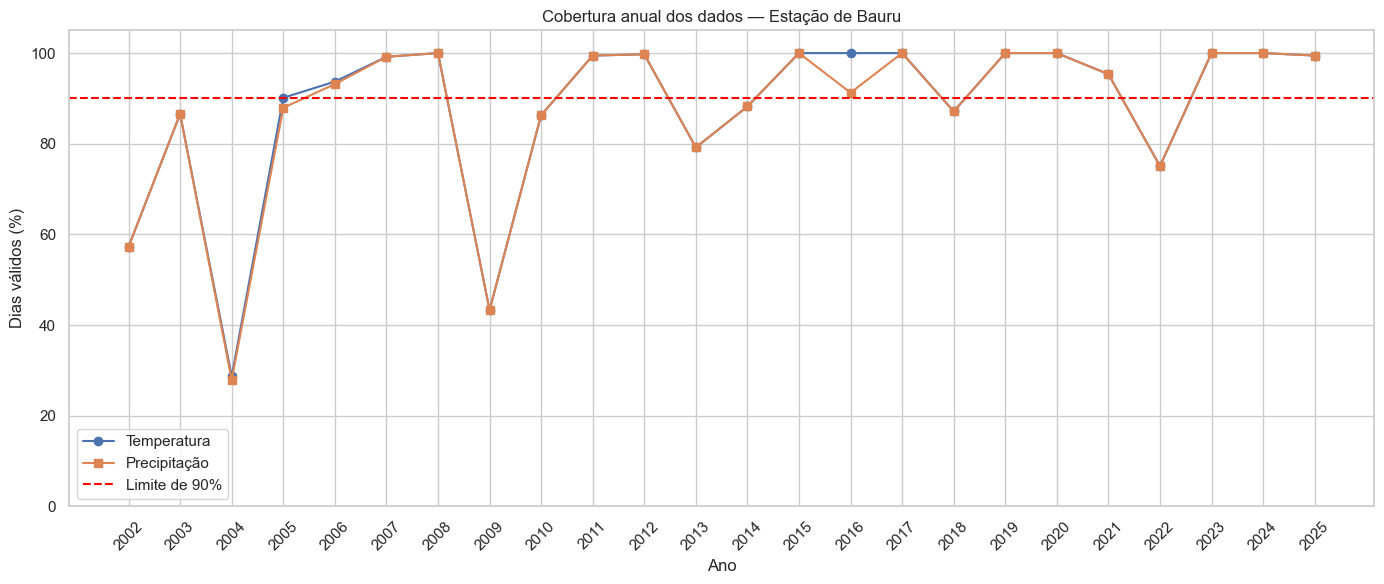

In [71]:
plt.figure(figsize=(14, 6))

plt.plot(
    cobertura_anual["ano"],
    cobertura_anual["cobertura_temperatura"] * 100,
    marker="o",
    label="Temperatura"
)

plt.plot(
    cobertura_anual["ano"],
    cobertura_anual["cobertura_precipitacao"] * 100,
    marker="s",
    label="Precipitação"
)

plt.axhline(
    90,
    color="red",
    linestyle="--",
    label="Limite de 90%"
)

plt.title("Cobertura anual dos dados — Estação de Bauru")
plt.xlabel("Ano")
plt.ylabel("Dias válidos (%)")
plt.ylim(0, 105)
plt.xticks(cobertura_anual["ano"], rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

## 15. Seleção dos anos adequados

A análise principal usa anos com cobertura mínima de 90%. O limite de 80% é utilizado apenas na análise de sensibilidade.

In [72]:
anos_temp_90 = cobertura_anual.loc[
    cobertura_anual["cobertura_temperatura"] >= 0.90,
    "ano"
].tolist()

anos_chuva_90 = cobertura_anual.loc[
    cobertura_anual["cobertura_precipitacao"] >= 0.90,
    "ano"
].tolist()

anos_temp_80 = cobertura_anual.loc[
    cobertura_anual["cobertura_temperatura"] >= 0.80,
    "ano"
].tolist()

anos_chuva_80 = cobertura_anual.loc[
    cobertura_anual["cobertura_precipitacao"] >= 0.80,
    "ano"
].tolist()

print(f"Temperatura, corte de 90% ({len(anos_temp_90)} anos):", anos_temp_90)
print(f"Precipitação, corte de 90% ({len(anos_chuva_90)} anos):", anos_chuva_90)
print(f"Temperatura, corte de 80% ({len(anos_temp_80)} anos):", anos_temp_80)
print(f"Precipitação, corte de 80% ({len(anos_chuva_80)} anos):", anos_chuva_80)

Temperatura, corte de 90% (15 anos): [2005, 2006, 2007, 2008, 2011, 2012, 2015, 2016, 2017, 2019, 2020, 2021, 2023, 2024, 2025]
Precipitação, corte de 90% (14 anos): [2006, 2007, 2008, 2011, 2012, 2015, 2016, 2017, 2019, 2020, 2021, 2023, 2024, 2025]
Temperatura, corte de 80% (19 anos): [2003, 2005, 2006, 2007, 2008, 2010, 2011, 2012, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2023, 2024, 2025]
Precipitação, corte de 80% (19 anos): [2003, 2005, 2006, 2007, 2008, 2010, 2011, 2012, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2023, 2024, 2025]


### Interpretação da cobertura

O critério de 90% selecionou **15 anos para temperatura** e **14 para chuva**. Com 80%, ambos passam a 19 anos. As lacunas de 2004, 2009 e 2022 justificam a filtragem e a análise de sensibilidade.

## 16. Construção das bases diária, mensal e anual

São criadas bases diária, mensal e anual. Para chuva, utilizam-se a média por dia válido e a proporção de dias com pelo menos 1 mm, evitando subestimar totais por causa das lacunas.

In [73]:
dados_diarios["valido_temperatura"] = (
    dados_diarios["observacoes_temperatura"] >= 22
)
dados_diarios["valido_precipitacao"] = (
    dados_diarios["observacoes_precipitacao"] >= 22
)
dados_diarios["dia_chuvoso"] = np.where(
    dados_diarios["precipitacao_total_mm"].notna(),
    dados_diarios["precipitacao_total_mm"] >= 1.0,
    np.nan
)

dados_mensais = (
    dados_diarios
    .groupby(["ano", "mes"], as_index=False)
    .agg(
        temperatura_media_c=("temperatura_media_c", "mean"),
        temperatura_maxima_c=("temperatura_maxima_c", "max"),
        temperatura_minima_c=("temperatura_minima_c", "min"),
        precipitacao_media_dia_valido_mm=("precipitacao_total_mm", "mean"),
        maior_chuva_diaria_mm=("precipitacao_total_mm", "max"),
        dias_validos_temperatura=("temperatura_media_c", "count"),
        dias_validos_precipitacao=("precipitacao_total_mm", "count"),
        dias_chuvosos=("dia_chuvoso", "sum")
    )
)

dados_mensais["dias_esperados"] = dados_mensais.apply(
    lambda linha: calendar.monthrange(int(linha["ano"]), int(linha["mes"]))[1],
    axis=1
)
dados_mensais["cobertura_temperatura"] = (
    dados_mensais["dias_validos_temperatura"] / dados_mensais["dias_esperados"]
)
dados_mensais["cobertura_precipitacao"] = (
    dados_mensais["dias_validos_precipitacao"] / dados_mensais["dias_esperados"]
)
dados_mensais["proporcao_dias_chuvosos"] = (
    dados_mensais["dias_chuvosos"] / dados_mensais["dias_validos_precipitacao"]
)
dados_mensais["temperatura_adequada_90"] = dados_mensais["cobertura_temperatura"] >= 0.90
dados_mensais["precipitacao_adequada_90"] = dados_mensais["cobertura_precipitacao"] >= 0.90

dados_anuais = (
    dados_diarios
    .groupby("ano", as_index=False)
    .agg(
        temperatura_media_c=("temperatura_media_c", "mean"),
        temperatura_maxima_c=("temperatura_maxima_c", "max"),
        temperatura_minima_c=("temperatura_minima_c", "min"),
        precipitacao_media_dia_valido_mm=("precipitacao_total_mm", "mean"),
        maior_chuva_diaria_mm=("precipitacao_total_mm", "max"),
        dias_validos_temperatura=("temperatura_media_c", "count"),
        dias_validos_precipitacao=("precipitacao_total_mm", "count"),
        dias_chuvosos=("dia_chuvoso", "sum")
    )
)

dados_anuais["dias_esperados"] = dados_anuais["ano"].apply(
    lambda ano: 366 if calendar.isleap(int(ano)) else 365
)
dados_anuais["cobertura_temperatura"] = (
    dados_anuais["dias_validos_temperatura"] / dados_anuais["dias_esperados"]
)
dados_anuais["cobertura_precipitacao"] = (
    dados_anuais["dias_validos_precipitacao"] / dados_anuais["dias_esperados"]
)
dados_anuais["proporcao_dias_chuvosos"] = (
    dados_anuais["dias_chuvosos"] / dados_anuais["dias_validos_precipitacao"]
)
dados_anuais["temperatura_adequada_90"] = dados_anuais["cobertura_temperatura"] >= 0.90
dados_anuais["precipitacao_adequada_90"] = dados_anuais["cobertura_precipitacao"] >= 0.90
dados_anuais["temperatura_adequada_80"] = dados_anuais["cobertura_temperatura"] >= 0.80
dados_anuais["precipitacao_adequada_80"] = dados_anuais["cobertura_precipitacao"] >= 0.80

display(dados_mensais.head())
display(dados_anuais)

,ano,mes,temperatura_media_c,temperatura_maxima_c,temperatura_minima_c,precipitacao_media_dia_valido_mm,maior_chuva_diaria_mm,dias_validos_temperatura,dias_validos_precipitacao,dias_chuvosos,dias_esperados,cobertura_temperatura,cobertura_precipitacao,proporcao_dias_chuvosos,temperatura_adequada_90,precipitacao_adequada_90
0,2002,1,23.290014,33.3,12.7,11.480000,72.6,25,25,11.0,31,0.806452,0.806452,0.440000,False,False
1,2002,2,21.845833,28.0,18.1,16.400000,41.6,3,3,2.0,28,0.107143,0.107143,0.666667,False,False
2,2002,3,24.596467,34.3,18.3,1.145455,13.0,22,22,4.0,31,0.709677,0.709677,0.181818,False,False
3,2002,4,26.179167,33.8,20.0,0.000000,0.0,1,1,0.0,30,0.033333,0.033333,0.000000,False,False
4,2002,5,19.623846,30.3,11.5,3.496296,28.0,27,27,7.0,31,0.870968,0.870968,0.259259,False,False


,ano,temperatura_media_c,temperatura_maxima_c,temperatura_minima_c,precipitacao_media_dia_valido_mm,maior_chuva_diaria_mm,dias_validos_temperatura,dias_validos_precipitacao,dias_chuvosos,dias_esperados,cobertura_temperatura,cobertura_precipitacao,proporcao_dias_chuvosos,temperatura_adequada_90,precipitacao_adequada_90,temperatura_adequada_80,precipitacao_adequada_80
0,2002,21.844585,38.7,4.5,3.648804,76.0,209,209,45.0,365,0.572603,0.572603,0.215311,False,False,False,False
1,2003,21.380632,37.6,6.3,3.648734,65.8,316,316,80.0,365,0.865753,0.865753,0.253165,False,False,True,True
2,2004,23.075720,35.2,13.8,5.782353,58.6,105,102,40.0,366,0.286885,0.278689,0.392157,False,False,False,False
3,2005,21.940945,36.2,5.2,3.986916,131.4,329,321,73.0,365,0.901370,0.879452,0.227414,True,False,True,True
4,2006,21.787525,36.9,4.9,3.241765,63.6,342,340,82.0,365,0.936986,0.931507,0.241176,True,True,True,True
5,2007,21.797345,37.0,4.2,4.473481,101.6,362,362,87.0,365,0.991781,0.991781,0.240331,True,True,True,True
6,2008,20.841322,36.4,4.9,3.471585,53.2,366,366,98.0,366,1.000000,1.000000,0.267760,True,True,True,True
7,2009,20.097738,34.6,4.7,2.943038,41.6,158,158,44.0,365,0.432877,0.432877,0.278481,False,False,False,False
8,2010,21.162810,35.9,5.9,2.303492,57.8,315,315,65.0,365,0.863014,0.863014,0.206349,False,False,True,True
9,2011,21.160251,37.4,2.1,3.875482,70.4,363,363,94.0,365,0.994521,0.994521,0.258953,True,True,True,True


### Validação e armazenamento das bases

As bases processadas são salvas com colunas de cobertura, validade e elegibilidade para tornar as exclusões auditáveis.

In [74]:
assert len(dados_diarios) == 8766, "Quantidade inesperada de dias"
assert dados_diarios["data_local"].min() == pd.Timestamp("2002-01-01")
assert dados_diarios["data_local"].max() == pd.Timestamp("2025-12-31")
assert not (dados_diarios["precipitacao_total_mm"].dropna() < 0).any()
assert len(dados_anuais) == 24
assert dados_mensais[["ano", "mes"]].duplicated().sum() == 0

caminho_diario = PASTA_PROCESSED / "bauru_dados_diarios_2002_2025.csv"
caminho_mensal = PASTA_PROCESSED / "bauru_dados_mensais_2002_2025.csv"
caminho_anual = PASTA_PROCESSED / "bauru_dados_anuais_2002_2025.csv"

dados_diarios.to_csv(caminho_diario, index=False, encoding="utf-8-sig")
dados_mensais.to_csv(caminho_mensal, index=False, encoding="utf-8-sig")
dados_anuais.to_csv(caminho_anual, index=False, encoding="utf-8-sig")

print("Base diária:", caminho_diario.relative_to(PASTA_PROJETO))
print("Base mensal:", caminho_mensal.relative_to(PASTA_PROJETO))
print("Base anual:", caminho_anual.relative_to(PASTA_PROJETO))

Base diária: data\processed\bauru_dados_diarios_2002_2025.csv
Base mensal: data\processed\bauru_dados_mensais_2002_2025.csv
Base anual: data\processed\bauru_dados_anuais_2002_2025.csv


## 17. Estatística descritiva

Para os anos com cobertura de 90%, são calculados tamanho da amostra, média, desvio-padrão, quartis, mediana, mínimo e máximo.

In [75]:
anuais_temp_90 = dados_anuais.loc[dados_anuais["temperatura_adequada_90"]].copy()
anuais_chuva_90 = dados_anuais.loc[dados_anuais["precipitacao_adequada_90"]].copy()

descritiva_temperatura = anuais_temp_90[[
    "temperatura_media_c",
    "temperatura_maxima_c",
    "temperatura_minima_c"
]].describe().T

descritiva_chuva = anuais_chuva_90[[
    "precipitacao_media_dia_valido_mm",
    "proporcao_dias_chuvosos",
    "maior_chuva_diaria_mm"
]].describe().T

print("Temperatura — anos com cobertura mínima de 90%")
display(descritiva_temperatura.round(3))
print("Chuva — anos com cobertura mínima de 90%")
display(descritiva_chuva.round(3))

Temperatura — anos com cobertura mínima de 90%


,count,mean,std,min,25%,50%,75%,max
temperatura_media_c,15.0,21.954,0.583,20.841,21.764,21.941,22.153,23.336
temperatura_maxima_c,15.0,38.060,1.518,36.200,36.950,37.900,39.100,41.600
temperatura_minima_c,15.0,4.827,1.972,1.600,3.800,4.900,6.050,9.400


Chuva — anos com cobertura mínima de 90%


,count,mean,std,min,25%,50%,75%,max
precipitacao_media_dia_valido_mm,14.0,3.263,0.627,2.262,2.926,3.237,3.733,4.473
proporcao_dias_chuvosos,14.0,0.246,0.030,0.190,0.228,0.242,0.259,0.304
maior_chuva_diaria_mm,14.0,72.557,24.332,44.800,56.250,65.500,84.050,131.800


### Interpretação descritiva

A temperatura média anual foi **21,95 °C** e a precipitação média foi **3,26 mm por dia válido**. Em média, **24,6% dos dias válidos** foram chuvosos. A dispersão confirma variação relevante entre anos.

## 18. Evolução da temperatura anual

O gráfico apresenta a temperatura média dos anos com cobertura de 90% e uma tendência linear descritiva.

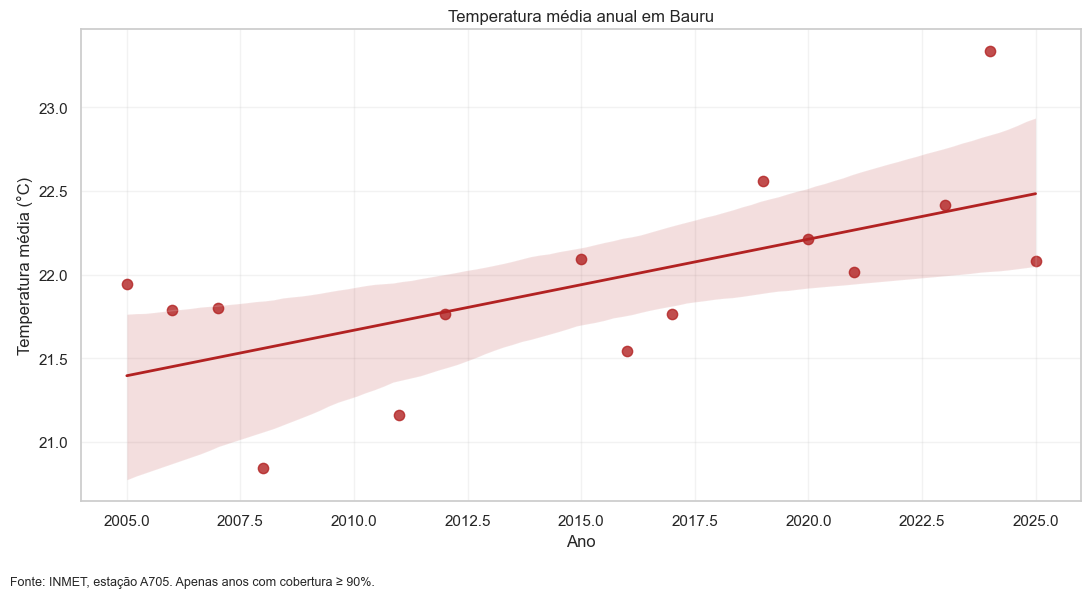

In [76]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.regplot(
    data=anuais_temp_90,
    x="ano",
    y="temperatura_media_c",
    ci=95,
    marker="o",
    color="#b22222",
    scatter_kws={"s": 55},
    line_kws={"linewidth": 2},
    ax=ax
)
ax.set_title("Temperatura média anual em Bauru")
ax.set_xlabel("Ano")
ax.set_ylabel("Temperatura média (°C)")
ax.grid(alpha=0.25)
fig.text(0.01, 0.01, "Fonte: INMET, estação A705. Apenas anos com cobertura ≥ 90%.", fontsize=9)
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(PASTA_FIGURES / "01_temperatura_anual.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretação da temperatura anual

Observa-se trajetória crescente, apesar da variação anual. O modelo formal estima **+0,54 °C por década**; 2024 é o maior valor entre os anos incluídos.

## 19. Evolução dos indicadores de chuva

O gráfico compara a precipitação média por dia válido e a proporção de dias com pelo menos 1 mm nos anos elegíveis.

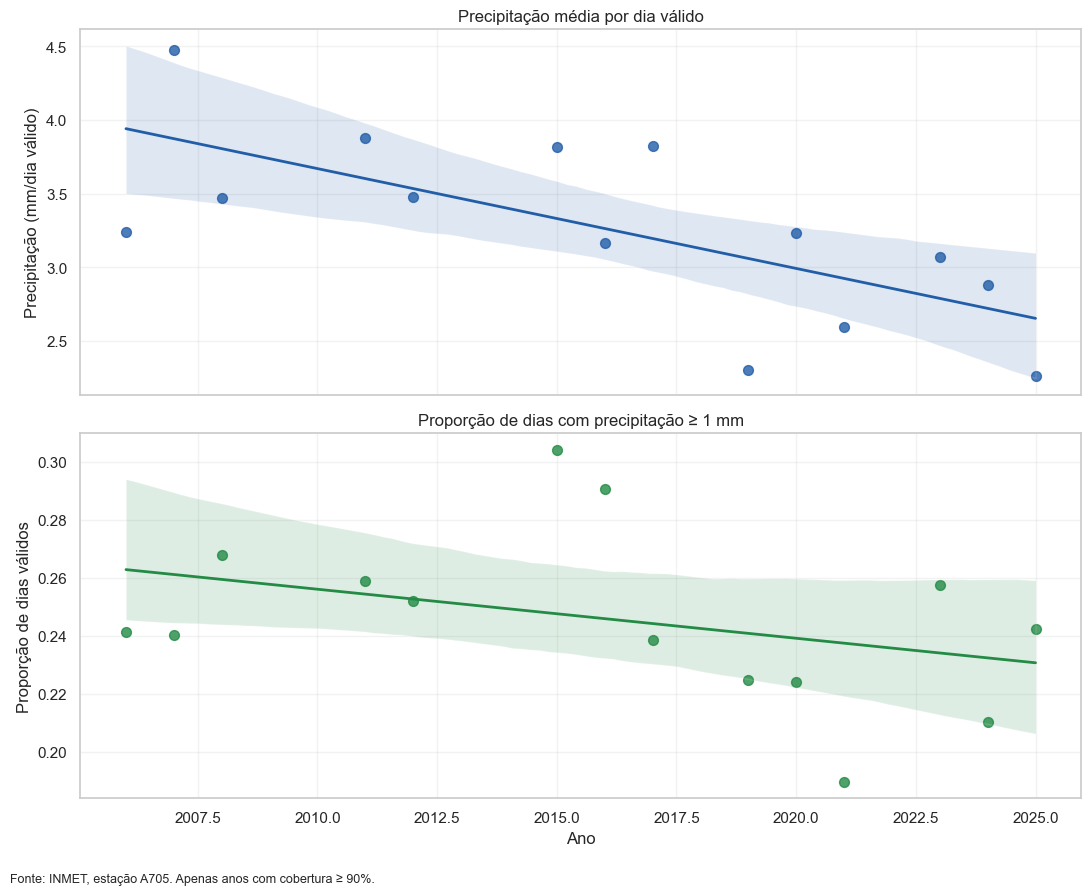

In [77]:
fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

sns.regplot(
    data=anuais_chuva_90,
    x="ano",
    y="precipitacao_media_dia_valido_mm",
    ci=95,
    color="#225ea8",
    scatter_kws={"s": 50},
    line_kws={"linewidth": 2},
    ax=axes[0]
)
axes[0].set_title("Precipitação média por dia válido")
axes[0].set_xlabel("")
axes[0].set_ylabel("Precipitação (mm/dia válido)")

sns.regplot(
    data=anuais_chuva_90,
    x="ano",
    y="proporcao_dias_chuvosos",
    ci=95,
    color="#238b45",
    scatter_kws={"s": 50},
    line_kws={"linewidth": 2},
    ax=axes[1]
)
axes[1].set_title("Proporção de dias com precipitação ≥ 1 mm")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Proporção de dias válidos")

for ax in axes:
    ax.grid(alpha=0.25)

fig.text(0.01, 0.01, "Fonte: INMET, estação A705. Apenas anos com cobertura ≥ 90%.", fontsize=9)
fig.tight_layout(rect=[0, 0.03, 1, 1])
fig.savefig(PASTA_FIGURES / "02_indicadores_chuva_anuais.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretação dos indicadores de chuva

A precipitação média diária apresenta tendência negativa de **−0,68 mm por década**. A frequência de dias chuvosos também diminui visualmente, mas sem significância estatística.

## 20. Sazonalidade mensal

O gráfico mostra o ciclo mensal de temperatura e precipitação usando meses com cobertura mínima de 90%.

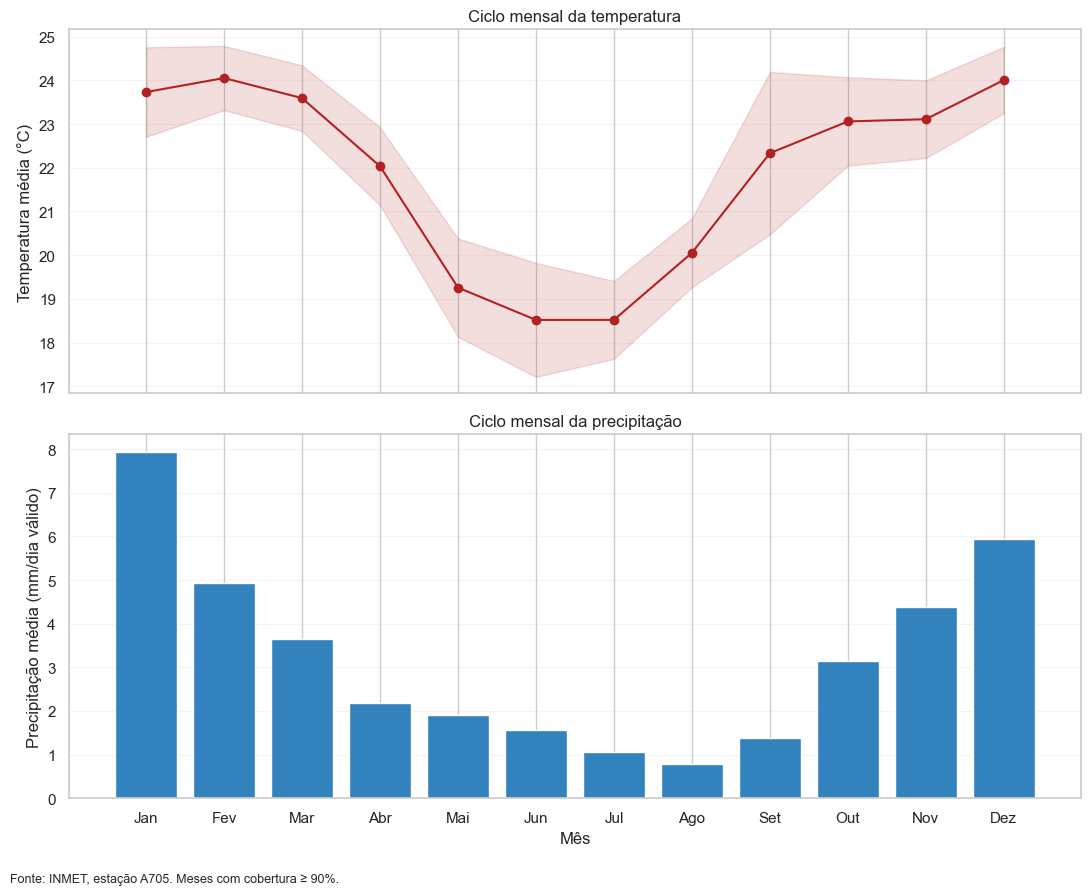

In [78]:
clima_temp_mensal = (
    dados_mensais.loc[dados_mensais["temperatura_adequada_90"]]
    .groupby("mes", as_index=False)
    .agg(
        temperatura_media_c=("temperatura_media_c", "mean"),
        desvio_temperatura=("temperatura_media_c", "std"),
        anos_validos=("ano", "count")
    )
)

clima_chuva_mensal = (
    dados_mensais.loc[dados_mensais["precipitacao_adequada_90"]]
    .groupby("mes", as_index=False)
    .agg(
        precipitacao_media_dia_valido_mm=("precipitacao_media_dia_valido_mm", "mean"),
        proporcao_dias_chuvosos=("proporcao_dias_chuvosos", "mean"),
        anos_validos=("ano", "count")
    )
)

nomes_meses = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
axes[0].plot(clima_temp_mensal["mes"], clima_temp_mensal["temperatura_media_c"], marker="o", color="#b22222")
axes[0].fill_between(
    clima_temp_mensal["mes"],
    clima_temp_mensal["temperatura_media_c"] - clima_temp_mensal["desvio_temperatura"],
    clima_temp_mensal["temperatura_media_c"] + clima_temp_mensal["desvio_temperatura"],
    alpha=0.15,
    color="#b22222"
)
axes[0].set_title("Ciclo mensal da temperatura")
axes[0].set_ylabel("Temperatura média (°C)")

axes[1].bar(clima_chuva_mensal["mes"], clima_chuva_mensal["precipitacao_media_dia_valido_mm"], color="#3182bd")
axes[1].set_title("Ciclo mensal da precipitação")
axes[1].set_xlabel("Mês")
axes[1].set_ylabel("Precipitação média (mm/dia válido)")
axes[1].set_xticks(range(1, 13), nomes_meses)

for ax in axes:
    ax.grid(alpha=0.2, axis="y")

fig.text(0.01, 0.01, "Fonte: INMET, estação A705. Meses com cobertura ≥ 90%.", fontsize=9)
fig.tight_layout(rect=[0, 0.03, 1, 1])
fig.savefig(PASTA_FIGURES / "03_sazonalidade_mensal.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretação da sazonalidade

O verão é mais quente e chuvoso, enquanto julho e agosto concentram o período mais seco e frio. Esse ciclo sazonal não representa, sozinho, mudança de longo prazo.

## 21. Distribuição da temperatura em dois períodos

O boxplot compara temperaturas médias diárias de 2002–2013 e 2014–2025, considerando apenas dias válidos.

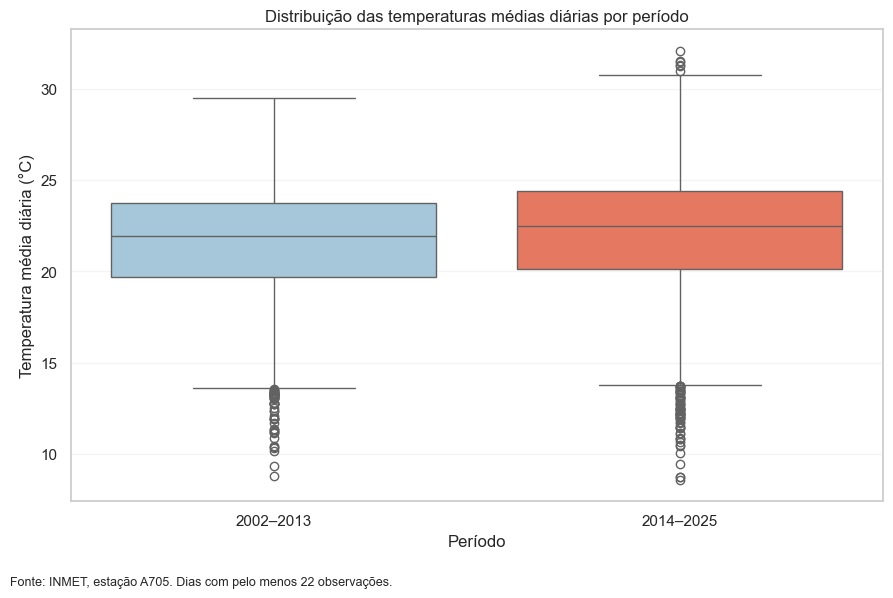

In [79]:
temperaturas_periodos = dados_diarios.loc[
    dados_diarios["temperatura_media_c"].notna(),
    ["ano", "temperatura_media_c"]
].copy()
temperaturas_periodos["periodo"] = np.where(
    temperaturas_periodos["ano"] <= 2013,
    "2002–2013",
    "2014–2025"
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(
    data=temperaturas_periodos,
    x="periodo",
    y="temperatura_media_c",
    hue="periodo",
    palette=["#9ecae1", "#fb6a4a"],
    legend=False,
    ax=ax
)
ax.set_title("Distribuição das temperaturas médias diárias por período")
ax.set_xlabel("Período")
ax.set_ylabel("Temperatura média diária (°C)")
ax.grid(alpha=0.2, axis="y")
fig.text(0.01, 0.01, "Fonte: INMET, estação A705. Dias com pelo menos 22 observações.", fontsize=9)
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(PASTA_FIGURES / "04_distribuicao_temperaturas.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretação da distribuição

O período 2014–2025 apresenta mediana e distribuição ligeiramente mais altas. A comparação é exploratória; a evidência principal vem dos modelos anuais com controle de cobertura.

## 22. Teste formal de tendência por regressão OLS

Foram ajustadas regressões OLS de cada indicador em função do ano, testando bilateralmente H₀: inclinação = 0, com α = 5%. A análise principal exige 90% de cobertura anual, e o limite de 80% é usado como sensibilidade.

In [80]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.stattools import durbin_watson


def ajustar_tendencia(base, variavel, filtro, nome, criterio):
    dados_modelo = base.loc[filtro, ["ano", variavel]].dropna().copy()
    dados_modelo["ano_centralizado"] = dados_modelo["ano"] - dados_modelo["ano"].mean()
    modelo = smf.ols(f"{variavel} ~ ano_centralizado", data=dados_modelo).fit()
    influencia = modelo.get_influence()
    cooks = influencia.cooks_distance[0]
    limite_cook = 4 / len(dados_modelo)
    anos_influentes = dados_modelo.loc[cooks > limite_cook, "ano"].astype(int).tolist()
    intervalo = modelo.conf_int().loc["ano_centralizado"]

    resumo = {
        "indicador": nome,
        "criterio_cobertura": criterio,
        "n_anos": len(dados_modelo),
        "inclinacao_anual": modelo.params["ano_centralizado"],
        "efeito_por_decada": modelo.params["ano_centralizado"] * 10,
        "ic95_inferior_decada": intervalo.iloc[0] * 10,
        "ic95_superior_decada": intervalo.iloc[1] * 10,
        "valor_p": modelo.pvalues["ano_centralizado"],
        "r_quadrado": modelo.rsquared,
        "durbin_watson": durbin_watson(modelo.resid),
        "limite_cook": limite_cook,
        "anos_influentes": ", ".join(map(str, anos_influentes)) if anos_influentes else "nenhum"
    }
    return modelo, dados_modelo, resumo


especificacoes = [
    ("temperatura_media_c", "temperatura_adequada", "Temperatura média anual"),
    ("precipitacao_media_dia_valido_mm", "precipitacao_adequada", "Precipitação média diária"),
    ("proporcao_dias_chuvosos", "precipitacao_adequada", "Proporção de dias chuvosos")
]

modelos_90 = {}
modelos_80 = {}
resumos_modelos = []

for variavel, prefixo, nome in especificacoes:
    modelo_90, base_90, resumo_90 = ajustar_tendencia(
        dados_anuais,
        variavel,
        dados_anuais[f"{prefixo}_90"],
        nome,
        "90%"
    )
    modelo_80, base_80, resumo_80 = ajustar_tendencia(
        dados_anuais,
        variavel,
        dados_anuais[f"{prefixo}_80"],
        nome,
        "80%"
    )
    modelos_90[variavel] = (modelo_90, base_90)
    modelos_80[variavel] = (modelo_80, base_80)
    resumos_modelos.extend([resumo_90, resumo_80])

resultados_regressoes = pd.DataFrame(resumos_modelos)
display(resultados_regressoes.round(4))
resultados_regressoes.to_csv(
    PASTA_PROCESSED / "resultados_regressoes.csv",
    index=False,
    encoding="utf-8-sig"
)

,indicador,criterio_cobertura,n_anos,inclinacao_anual,efeito_por_decada,ic95_inferior_decada,ic95_superior_decada,valor_p,r_quadrado,durbin_watson,limite_cook,anos_influentes
0,Temperatura média anual,90%,15,0.0544,0.5437,0.1455,0.9420,0.0113,0.4009,1.7779,0.2667,2024
1,Temperatura média anual,80%,19,0.0568,0.5684,0.2499,0.8868,0.0015,0.4548,1.6132,0.2105,2024
2,Precipitação média diária,90%,14,-0.0678,-0.6776,-1.1236,-0.2315,0.0062,0.4772,3.0394,0.2857,"2006, 2007"
3,Precipitação média diária,80%,19,-0.0516,-0.5164,-0.9173,-0.1154,0.0146,0.3028,2.6963,0.2105,nenhum
4,Proporção de dias chuvosos,90%,14,-0.0017,-0.0169,-0.0444,0.0106,0.2047,0.1304,1.6058,0.2857,nenhum
5,Proporção de dias chuvosos,80%,19,-0.0007,-0.0074,-0.0283,0.0136,0.4691,0.0313,2.1599,0.2105,nenhum


## 23. Diagnóstico dos modelos principais

Os modelos foram avaliados por resíduos versus valores ajustados, QQ-plot e distância de Cook. Como há poucos anos válidos, padrões nos resíduos ou anos influentes exigem cautela na interpretação.

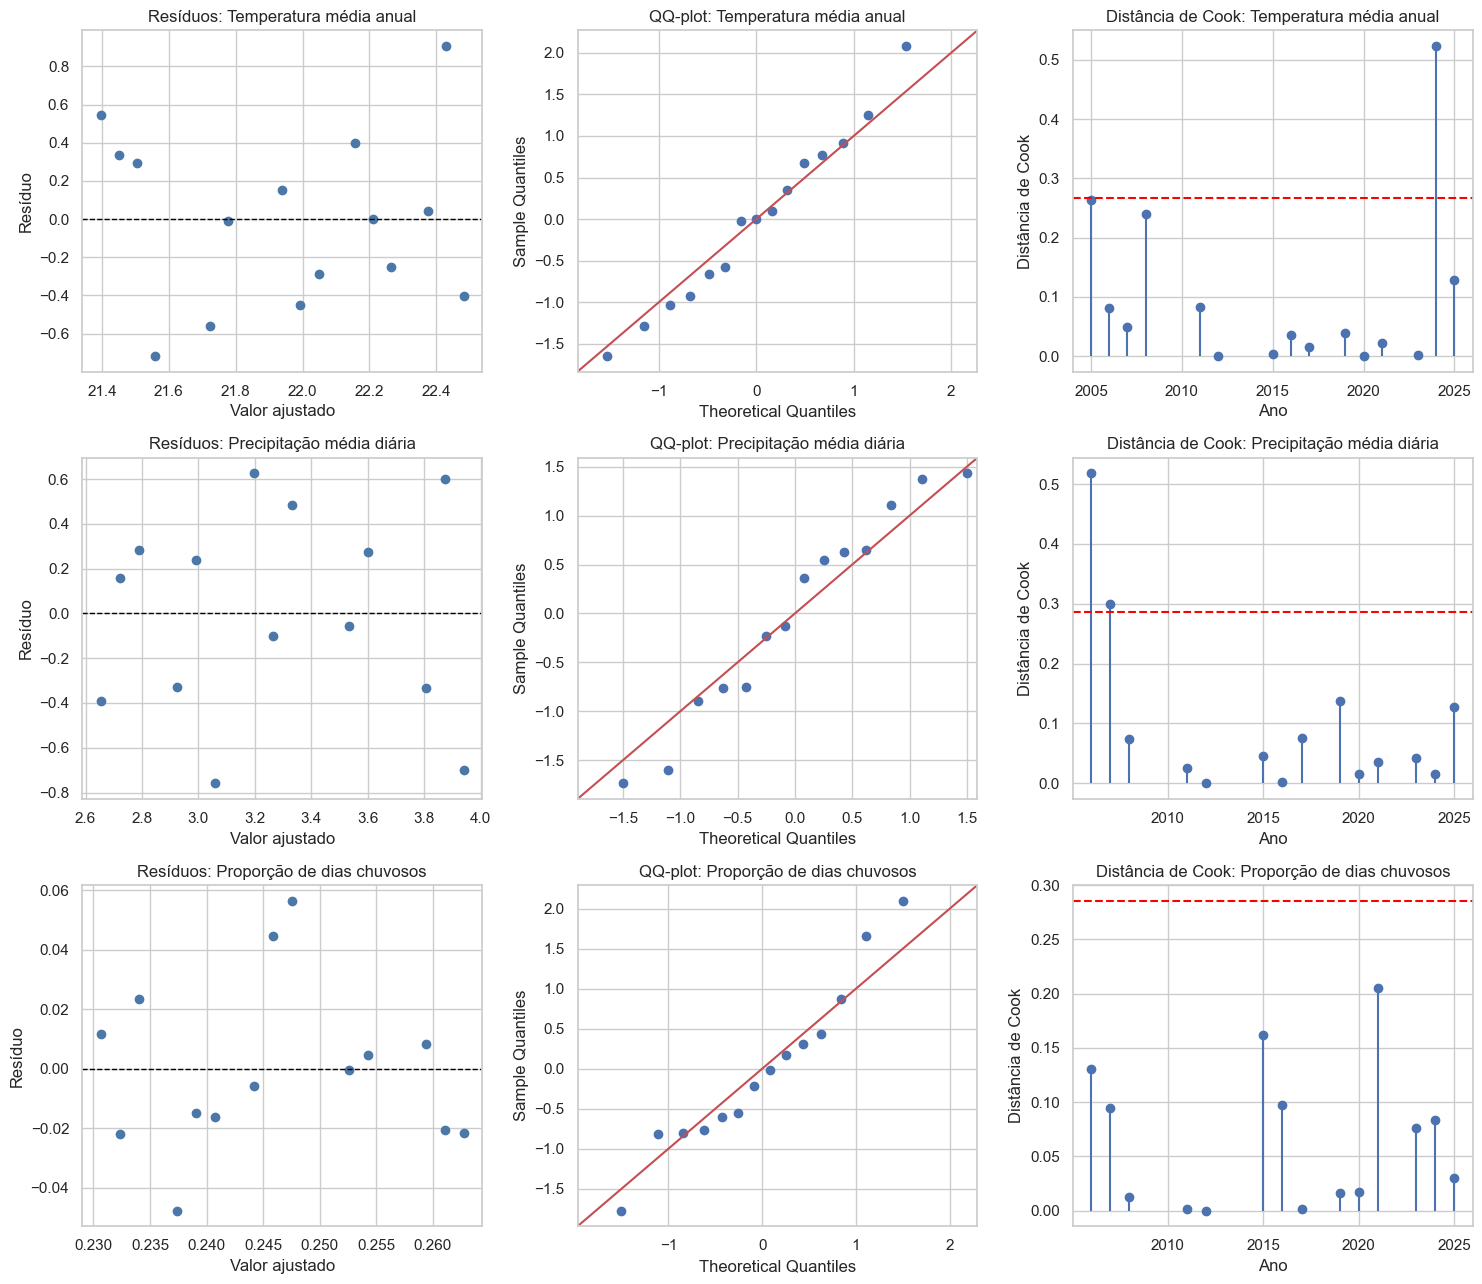

In [81]:
fig, axes = plt.subplots(3, 3, figsize=(15, 13))

for linha, (variavel, _, nome) in enumerate(especificacoes):
    modelo, base_modelo = modelos_90[variavel]
    influencia = modelo.get_influence()
    cooks = influencia.cooks_distance[0]

    axes[linha, 0].scatter(modelo.fittedvalues, modelo.resid, color="#4c78a8")
    axes[linha, 0].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[linha, 0].set_title(f"Resíduos: {nome}")
    axes[linha, 0].set_xlabel("Valor ajustado")
    axes[linha, 0].set_ylabel("Resíduo")

    sm.qqplot(modelo.resid, line="45", fit=True, ax=axes[linha, 1])
    axes[linha, 1].set_title(f"QQ-plot: {nome}")

    axes[linha, 2].stem(base_modelo["ano"], cooks, basefmt=" ")
    axes[linha, 2].axhline(4 / len(base_modelo), color="red", linestyle="--")
    axes[linha, 2].set_title(f"Distância de Cook: {nome}")
    axes[linha, 2].set_xlabel("Ano")
    axes[linha, 2].set_ylabel("Distância de Cook")

fig.tight_layout()
fig.savefig(PASTA_FIGURES / "05_diagnosticos_regressoes.png", dpi=300, bbox_inches="tight")
plt.show()